- import libraries and tools 

In [39]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()



- read and run dataset 

In [40]:
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [41]:
df.shape

(1470, 35)

- the  dataset we have consists of `1470` rows and `35` columns , at frist glance it looks like a clean dataset.

## 🎯 Project Objective
- Build a **Binary Classification** model to predict attrition (Yes/No)
- Identify the **most important features** driving employee attrition
- Provide **actionable insights** to HR teams to reduce turnover rate
- Handle **Class Imbalance** using proper techniques (SMOTE / class weighting)

## 📊 Target Variable 
- **Target column:** `Attrition`
- **Values:** `Yes` (employee left) / `No` (employee stayed)
- **Problem type:** Binary Classification
- **Main challenge:** Class Imbalance (~16% Yes vs ~84% No)

## 📈 Success Metrics 
Since the dataset is imbalanced, primary evaluation metrics:
- **ROC-AUC Score** — primary metric
- **F1-Score** — especially for the minority class (Yes)
- **Precision & Recall** — balance between both
- **Confusion Matrix** — full error analysis

## 💡 Expected Output 
Final model output:
1. Probability of attrition for each employee (0 to 1)
2. Top contributing features using **SHAP Values**
3. Actionable HR recommendations based on model findings

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [43]:
df.describe().round(2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [44]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

- column categories :  

- **personal information** :  Age، Gender، MaritalStatus، Education، EducationField 
- **job and organization** : Department، JobRole، JobLevel، BusinessTravel، OverTime
- **Financial** : MonthlyIncome، HourlyRate، DailyRate، MonthlyRate، PercentSalaryHike، StockOptionLevel
- **work history** : TotalWorkingYears، YearsAtCompany، YearsInCurrentRole، YearsSinceLastPromotion، YearsWithCurrManager، NumCompaniesWorked
- **satisfaction and performance**: JobSatisfaction، EnvironmentSatisfaction، RelationshipSatisfaction، WorkLifeBalance، PerformanceRating، JobInvolvement، TrainingTimesLastYear


In [45]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [46]:
df.isnull().sum().sum()

np.int64(0)

In [47]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

- deleting columns that don't give us specific information 

In [48]:
df.drop(['Over18','EmployeeNumber','EmployeeCount','StandardHours'],axis=1,inplace=True)

In [49]:
# target column 
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [50]:
print(df['Attrition'].unique())

[1 0]


In [51]:
print(df['Attrition'].unique())
print(df['Attrition'].dtype)

[1 0]
int64


In [52]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df['Attrition'].unique())

['Yes' 'No']


In [53]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(df['Attrition'].unique())

[1 0]


In [54]:
df.drop(['Over18','EmployeeNumber','EmployeeCount','StandardHours'],axis=1,inplace=True)

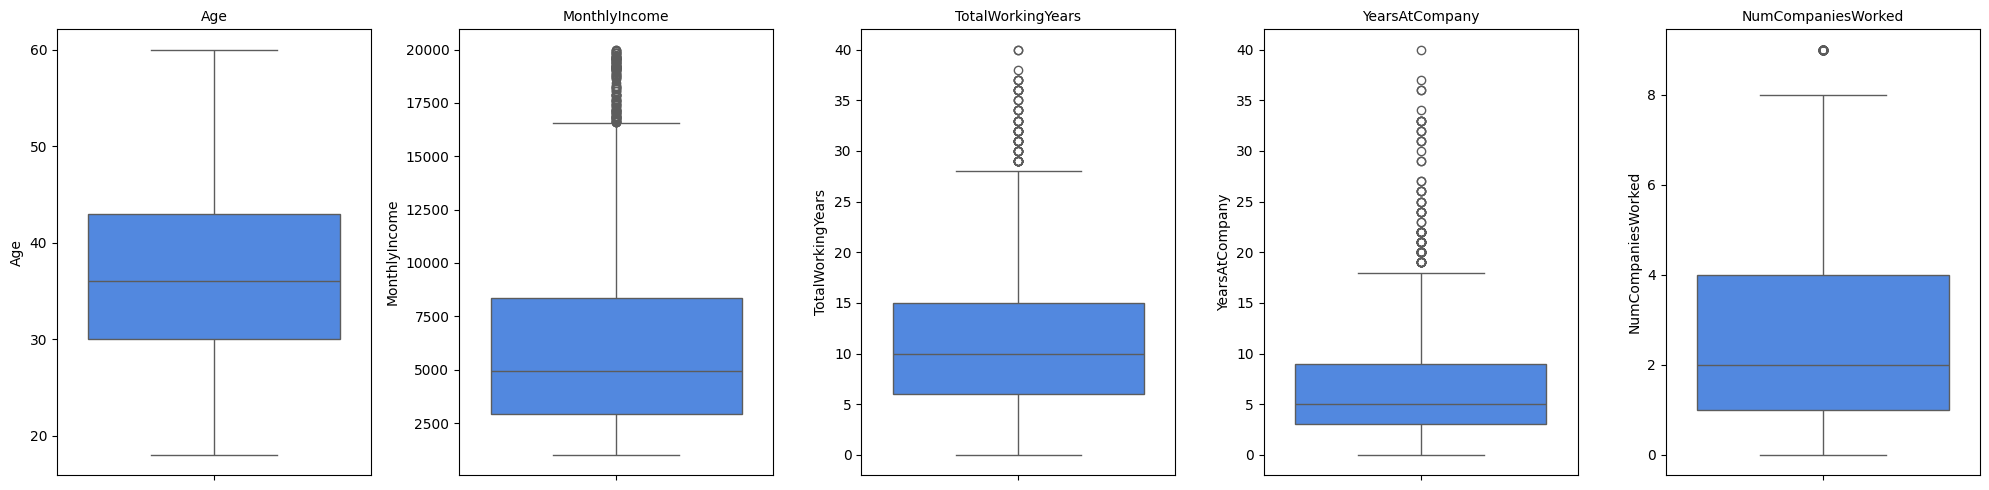

In [55]:

cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 
        'YearsAtCompany', 'NumCompaniesWorked']

fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#3B82F6')
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

In [56]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

cols_to_clean = ['MonthlyIncome', 'TotalWorkingYears', 'NumCompaniesWorked']

for col in cols_to_clean:
    df = remove_outliers_iqr(df, col)

In [57]:
df.shape

(1470, 31)

In [58]:
print(df.select_dtypes(include='object').columns.tolist())

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [59]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['OverTime'] = le.fit_transform(df['OverTime'])

In [60]:
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 
                                  'EducationField', 'JobRole', 
                                  'MaritalStatus'], drop_first=True)

In [61]:

print(df.dtypes.value_counts())

int64      24
bool       19
float64     2
Name: count, dtype: int64


In [62]:
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})
print(df.dtypes.value_counts())

int64      43
float64     2
Name: count, dtype: int64


In [63]:
print(df.shape)
print(df['Attrition'].value_counts())

(1470, 45)
Attrition
0    1233
1     237
Name: count, dtype: int64


In [64]:
df.shape

(1470, 45)

**done encoding**

**start EDA**